# Baseline Momentum Strategy

This notebook documents the baseline momentum strategy used as a benchmark for later machine-learning models.

The notebook covers:

1. motivation for the benchmark  
2. momentum signal construction  
3. portfolio formation logic  
4. gross and cost-adjusted results  
5. interpretation of the baseline performance  

The objective is to create a transparent financial reference point before comparing more complex predictive models.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml
src exists: True


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config
from src.utils.paths import get_experiment_dir
from src.utils.plotting import (
    STYLE,
    get_model_color,
    plot_equity_curve,
    plot_drawdown,
    plot_turnover,
    plot_multi_series,
    plot_metric_bar,
)

In [3]:
NOTEBOOK_NAME = "notebook03"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Tables dir :", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)

Tables dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook03
Figures dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook03


In [4]:
def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> None:
    path = TABLES_DIR / filename
    df.to_csv(path, index=index)
    print(f"Saved table -> {path}")


def fig_path(filename: str) -> str:
    return str(FIGURES_DIR / filename)

## 1. Why a baseline momentum strategy is needed

A baseline momentum strategy provides an economically interpretable reference point.

This benchmark is important because:

- it represents a simple and widely used quantitative stock-selection rule
- it does not require supervised machine learning
- it shows whether more complex models add value beyond a standard momentum rule

Later model comparisons should therefore be interpreted relative to this baseline.

In [5]:
baseline_dir = PROJECT_ROOT / "experiments" / "results" / "exp01_baseline_monthly"

metrics_train_path = baseline_dir / "metrics_train.json"
metrics_test_path = baseline_dir / "metrics_test_2025.json"
metrics_train_costs_path = baseline_dir / "metrics_train_with_costs.json"
metrics_test_costs_path = baseline_dir / "metrics_test_2025_with_costs.json"

equity_train_path = baseline_dir / "equity_train.csv"
equity_test_path = baseline_dir / "equity_test_2025.csv"

print("Baseline dir:", baseline_dir)
print("Train metrics exists:", metrics_train_path.exists())
print("Test metrics exists:", metrics_test_path.exists())
print("Train equity exists:", equity_train_path.exists())
print("Test equity exists:", equity_test_path.exists())


Baseline dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp01_baseline_monthly
Train metrics exists: True
Test metrics exists: True
Train equity exists: True
Test equity exists: True


In [6]:
with open(metrics_train_path, "r") as f:
    baseline_metrics_train = json.load(f)

with open(metrics_test_path, "r") as f:
    baseline_metrics_test = json.load(f)

with open(metrics_train_costs_path, "r") as f:
    baseline_metrics_train_costs = json.load(f)

with open(metrics_test_costs_path, "r") as f:
    baseline_metrics_test_costs = json.load(f)

equity_train = pd.read_csv(equity_train_path, index_col=0).squeeze("columns")
equity_test = pd.read_csv(equity_test_path, index_col=0).squeeze("columns")

equity_train.index = pd.to_datetime(equity_train.index)
equity_test.index = pd.to_datetime(equity_test.index)

In [7]:
baseline_metrics_train, baseline_metrics_test

({'cumulative_return': 1.5986930528021168,
  'annualized_return': 0.10020977334600367,
  'annualized_volatility': 0.13073020567159008,
  'max_drawdown': -0.25528742834684415,
  'sharpe_ratio': 0.7999089362698278,
  'avg_turnover': 0.20625,
  'median_turnover': 0.2,
  'max_turnover': 0.55},
 {'cumulative_return': 0.38087003830555877,
  'annualized_return': 0.38087003830555877,
  'annualized_volatility': 0.1307125092343079,
  'max_drawdown': -0.06820708568143807,
  'sharpe_ratio': 2.5625897601199936,
  'avg_turnover': 0.13749999999999998,
  'median_turnover': 0.125,
  'max_turnover': 0.35})

In [8]:
baseline_setup = pd.DataFrame(
    {
        "setting": [
            "strategy_name",
            "signal_frequency",
            "selection_rule",
            "top_percentage",
            "weighting",
            "transaction_cost_rates",
        ],
        "value": [
            "Baseline Momentum",
            "monthly",
            "top stocks by momentum signal",
            getattr(config, "TOP_PERCENTAGE", None),
            "equal weight",
            getattr(config, "TRANSACTION_COST_RATES", None),
        ],
    }
)
baseline_setup

,setting,value
0,strategy_name,Baseline Momentum
1,signal_frequency,monthly
2,selection_rule,top stocks by momentum signal
3,top_percentage,0.2
4,weighting,equal weight
5,transaction_cost_rates,"[0.0, 0.001, 0.002]"


In [9]:
save_table(baseline_setup, "baseline_setup_summary.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook03\baseline_setup_summary.csv


## 2. Portfolio construction logic

The baseline strategy forms a portfolio using a momentum-style ranking signal.

At each rebalance date:

1. a momentum signal is computed for all eligible stocks  
2. stocks are ranked from strongest to weakest  
3. the top fraction is selected  
4. equal weights are assigned across selected names  
5. portfolio returns are measured in the following month  

This provides a transparent benchmark for later model-driven stock ranking.

In [10]:
combined_baseline_metrics = pd.DataFrame(
    {
        "metric": list(baseline_metrics_train.keys()),
        "train_2015_2024": [baseline_metrics_train[k] for k in baseline_metrics_train.keys()],
        "test_2025": [baseline_metrics_test[k] for k in baseline_metrics_train.keys()],
    }
)
combined_baseline_metrics

,metric,train_2015_2024,test_2025
0,cumulative_return,1.598693,0.380870
1,annualized_return,0.100210,0.380870
2,annualized_volatility,0.130730,0.130713
3,max_drawdown,-0.255287,-0.068207
4,sharpe_ratio,0.799909,2.562590
5,avg_turnover,0.206250,0.137500
6,median_turnover,0.200000,0.125000
7,max_turnover,0.550000,0.350000


In [11]:
save_table(combined_baseline_metrics, "baseline_strategy_metrics_train_test.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook03\baseline_strategy_metrics_train_test.csv


In [12]:
turnover_summary_table = pd.DataFrame(
    {
        "metric": ["avg_turnover", "median_turnover", "max_turnover"],
        "train_2015_2024": [
            baseline_metrics_train["avg_turnover"],
            baseline_metrics_train["median_turnover"],
            baseline_metrics_train["max_turnover"],
        ],
        "test_2025": [
            baseline_metrics_test["avg_turnover"],
            baseline_metrics_test["median_turnover"],
            baseline_metrics_test["max_turnover"],
        ],
    }
)
turnover_summary_table

,metric,train_2015_2024,test_2025
0,avg_turnover,0.20625,0.1375
1,median_turnover,0.20000,0.1250
2,max_turnover,0.55000,0.3500


In [13]:
save_table(turnover_summary_table, "baseline_turnover_summary.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook03\baseline_turnover_summary.csv


In [14]:
baseline_train_costs_df = pd.DataFrame(baseline_metrics_train_costs).T.reset_index().rename(columns={"index": "cost_scenario"})
baseline_test_costs_df = pd.DataFrame(baseline_metrics_test_costs).T.reset_index().rename(columns={"index": "cost_scenario"})

baseline_train_costs_df, baseline_test_costs_df

(  cost_scenario  cumulative_return  annualized_return  annualized_volatility  \
 0     cost_0bps           1.598693           0.100210               0.130730   
 1    cost_10bps           1.535721           0.097514               0.130693   
 2    cost_20bps           1.474258           0.094824               0.130656   
 
    max_drawdown  sharpe_ratio  avg_turnover  median_turnover  max_turnover  
 0     -0.255287      0.799909       0.20625              0.2          0.55  
 1     -0.255633      0.781201       0.20625              0.2          0.55  
 2     -0.255979      0.762475       0.20625              0.2          0.55  ,
   cost_scenario  cumulative_return  annualized_return  annualized_volatility  \
 0     cost_0bps           0.380870           0.380870               0.130713   
 1    cost_10bps           0.378629           0.378629               0.130846   
 2    cost_20bps           0.376391           0.376391               0.130980   
 
    max_drawdown  sharpe_ratio  avg

In [15]:
save_table(baseline_train_costs_df, "baseline_train_cost_adjusted_metrics.csv", index=False)
save_table(baseline_test_costs_df, "baseline_test_cost_adjusted_metrics.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook03\baseline_train_cost_adjusted_metrics.csv
Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook03\baseline_test_cost_adjusted_metrics.csv


## 3. Turnover information

Turnover information is available in the saved summary metrics for the baseline strategy, including average, median, and maximum turnover.

The full turnover time series was not saved in the original baseline experiment, so turnover is discussed through summary statistics rather than a dedicated time-series plot.

## 4. Equity curves

The equity curve shows how the cumulative value of the strategy evolves through time.

Separate train and test plots are shown below, followed by a combined view.

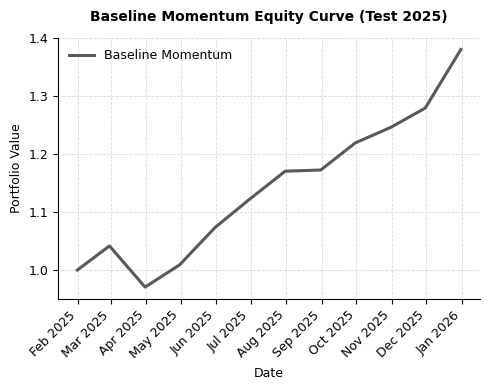

In [16]:
plot_equity_curve(
    equity_test,
    title="Baseline Momentum Equity Curve (Test 2025)",
    save_path=fig_path("baseline_equity_test.png"),
    label="Baseline Momentum",
    color=get_model_color("baseline"),
    show=True,
)

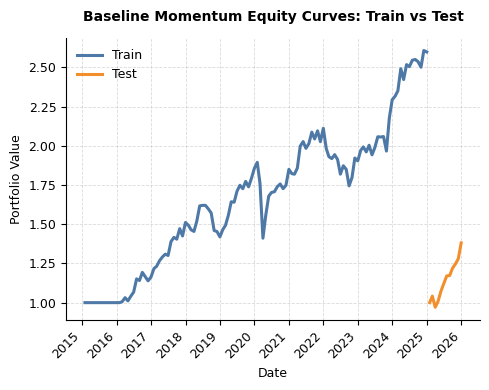

In [17]:
plot_multi_series(
    series_map={
        "Train": equity_train,
        "Test": equity_test,
    },
    title="Baseline Momentum Equity Curves: Train vs Test",
    ylabel="Portfolio Value",
    color_map={
        "Train": "#4E79A7",
        "Test": "#F28E2B",
    },
    save_path=fig_path("baseline_equity_train_vs_test.png"),
    show=True,
)

## 5. Drawdowns

The drawdown plot shows the percentage decline from the running peak of the equity curve.

This helps evaluate downside risk beyond average return.

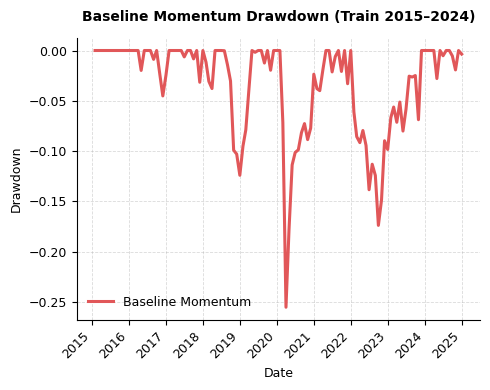

In [18]:
plot_drawdown(
    equity_train,
    title="Baseline Momentum Drawdown (Train 2015–2024)",
    save_path=fig_path("baseline_drawdown_train.png"),
    label="Baseline Momentum",
    color="#E15759",
    show=True,
)

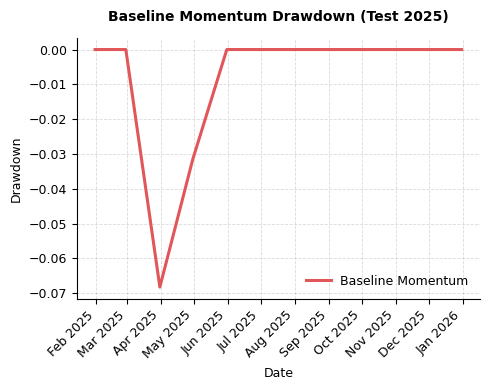

In [19]:
plot_drawdown(
    equity_test,
    title="Baseline Momentum Drawdown (Test 2025)",
    save_path=fig_path("baseline_drawdown_test.png"),
    label="Baseline Momentum",
    color="#E15759",
    show=True,
)

## 6. Cost-adjusted performance

Gross strategy results describe the portfolio before transaction costs.

Net strategy results adjust for turnover-based costs and provide a more realistic estimate of implementable performance.

In [20]:
cost_comparison_test = baseline_test_costs_df[["cost_scenario", "cumulative_return", "sharpe_ratio"]].copy()
cost_comparison_test

,cost_scenario,cumulative_return,sharpe_ratio
0,cost_0bps,0.380870,2.562590
1,cost_10bps,0.378629,2.547364
2,cost_20bps,0.376391,2.532157


In [21]:
save_table(cost_comparison_test, "baseline_test_cost_comparison_simple.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook03\baseline_test_cost_comparison_simple.csv


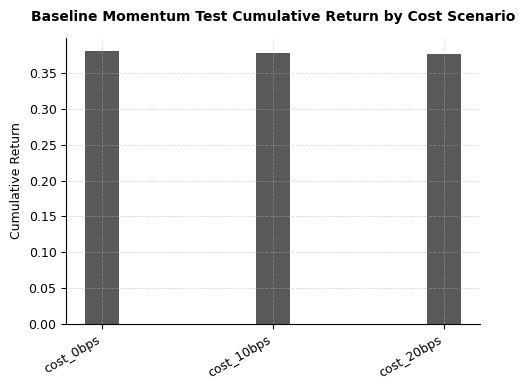

In [22]:
cost_return_series = cost_comparison_test.set_index("cost_scenario")["cumulative_return"]

plot_metric_bar(
    cost_return_series,
    title="Baseline Momentum Test Cumulative Return by Cost Scenario",
    ylabel="Cumulative Return",
    save_path=fig_path("baseline_test_cumulative_return_by_cost.png"),
    color_map={idx: get_model_color("baseline") for idx in cost_return_series.index},
    show=True,
)

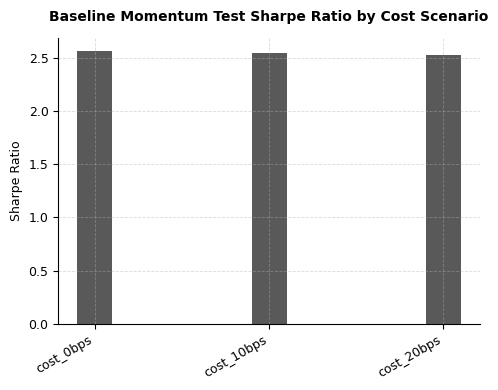

In [23]:
cost_sharpe_series = cost_comparison_test.set_index("cost_scenario")["sharpe_ratio"]

plot_metric_bar(
    cost_sharpe_series,
    title="Baseline Momentum Test Sharpe Ratio by Cost Scenario",
    ylabel="Sharpe Ratio",
    save_path=fig_path("baseline_test_sharpe_by_cost.png"),
    color_map={idx: get_model_color("baseline") for idx in cost_sharpe_series.index},
    show=True,
)

## 7. Interpretation

The baseline momentum strategy provides an economically meaningful benchmark.

Key observations from the results should be interpreted in terms of:

- return generation  
- risk and drawdown  
- turnover level  
- cost sensitivity  
- robustness between the training period and the 2025 test period  

This benchmark is important because later machine-learning models must be judged not only by prediction accuracy, but also by whether they outperform this simple and interpretable strategy.

In [24]:
baseline_findings = pd.DataFrame(
    {
        "finding": [
            "Baseline provides a transparent non-ML benchmark",
            "Train and test performance can be compared directly",
            "Turnover level is available through summary metrics",
            "Transaction costs reduce performance but do not eliminate the benchmark's usefulness",
            "Later ML models should be evaluated relative to this benchmark",
        ]
    }
)
baseline_findings

,finding
0,Baseline provides a transparent non-ML benchmark
1,Train and test performance can be compared dir...
2,Turnover level is available through summary me...
3,Transaction costs reduce performance but do no...
4,Later ML models should be evaluated relative t...


In [25]:
save_table(baseline_findings, "baseline_key_findings.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook03\baseline_key_findings.csv


## 8. Final conclusion

The baseline momentum strategy serves as the reference point for all subsequent model comparisons.

It provides:

- a simple and interpretable ranking rule  
- realistic train/test portfolio statistics  
- turnover summary statistics  
- a cost-sensitive benchmark for evaluating whether machine-learning models add value  

The next notebook introduces the linear Ridge model as the first supervised-learning benchmark.